# Notebook 04: Boosting Models
Training and evaluating gradient boosting models (XGBoost, LightGBM, CatBoost)

## Cell 1 — Imports

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from src.data.data_loader import (
    load_config,
    load_dataset,
    sample_dataset
)
from src.data.preprocessing import (
    basic_preprocessing_pipeline
)
from src.features.feature_engineering import (
    feature_engineering_pipeline
)
from src.features.encoder import (
    encode_categorical_columns
)
from src.models.train_test_split import (
    temporal_train_test_split,
    split_features_target
)
from src.models.smote_pipeline import (
    apply_smote
)
from src.models.boosting_models import (
    train_xgboost,
    train_lightgbm,
    train_catboost
)
from src.models.baseline_models import (
    generate_predictions
)
from src.evaluation.metrics import (
    evaluate_model,
    plot_confusion_matrix
)
from src.evaluation.cross_validation import (
    run_cross_validation
)

## Cell 2 — Load + Prepare Dataset

In [2]:
config = load_config()
df = load_dataset(config)
df = sample_dataset(df, config)
df = basic_preprocessing_pipeline(df)
df = feature_engineering_pipeline(df)
train_df, test_df = temporal_train_test_split(df)
X_train, X_test, y_train, y_test = split_features_target(
    train_df,
    test_df
)
X_train, X_test, encoders = encode_categorical_columns(
    X_train,
    X_test
)
X_train_smote, y_train_smote = apply_smote(
    X_train,
    y_train
)

print(f"\n✓ Data prepared successfully!")
print(f"  Training set: {X_train_smote.shape}")
print(f"  Test set: {X_test.shape}")


Loading dataset from:
/Users/nurnafisfuad/Desktop/AccidentXAI/data/raw/US_Accidents_March23.csv


Dataset loaded successfully.


Sampling 100000 rows...


Starting preprocessing pipeline...

Converting Start_Time to datetime format...
Removed 85 duplicate rows.

Selected relevant columns.

Dropping high-missing columns:

[]

Missing values handled successfully.

Preprocessing completed successfully.


Starting feature engineering pipeline...

Creating temporal features...

Creating rush-hour feature...

Creating night-driving feature...

Simplifying target variable...


Feature engineering completed.


Performing temporal split...

Train Shape: (71919, 30)
Test Shape: (16318, 30)

Separating features and target...

X_train shape: (71919, 29)
X_test shape: (16318, 29)

Encoding categorical columns...

Encoding completed.


Applying SMOTE...

Before SMOTE:

Counter({0: 54138, 1: 17781})

After SMOTE:

Counter({0: 54138, 1: 54138})

✓ Data prepared successfully!
  Training set: (108276, 

## Cell 3 — Train XGBoost

In [3]:
xgb_model = train_xgboost(
    X_train_smote,
    y_train_smote
)


Training XGBoost...

XGBoost training completed.



## Cell 4 — XGBoost Predictions

In [4]:
xgb_preds, xgb_probs = generate_predictions(
    xgb_model,
    X_test
)

## Cell 5 — XGBoost Evaluation

In [5]:
evaluate_model(
    y_test,
    xgb_preds,
    xgb_probs,
    model_name="XGBoost"
)

XGBoost Evaluation

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     14872
           1       0.29      0.05      0.08      1446

    accuracy                           0.90     16318
   macro avg       0.60      0.52      0.52     16318
weighted avg       0.86      0.90      0.87     16318


ROC-AUC Score: 0.6945


## Cell 6 — XGBoost Confusion Matrix

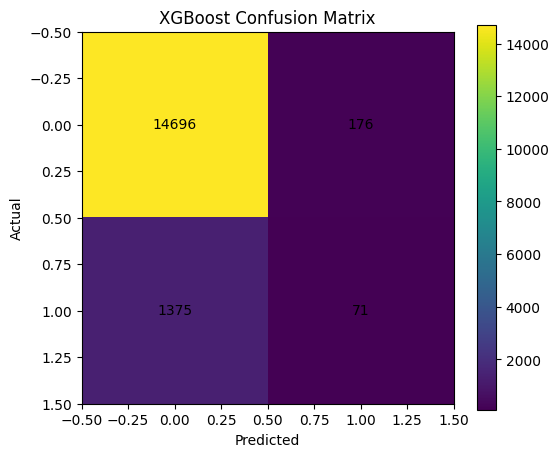

In [6]:
plot_confusion_matrix(
    y_test,
    xgb_preds,
    model_name="XGBoost"
)

## Cell 7 — XGBoost Cross Validation

In [7]:
run_cross_validation(
    xgb_model,
    X_train_smote,
    y_train_smote
)


Running 5-Fold Cross Validation...

Scores: [0.43015538 0.71590536 0.92345817 0.92350078 0.92503983]

Mean Score: 0.7836
Std Dev: 0.1942


array([0.43015538, 0.71590536, 0.92345817, 0.92350078, 0.92503983])

## Cell 8 — Train LightGBM

In [8]:
lgbm_model = train_lightgbm(
    X_train_smote,
    y_train_smote
)


Training LightGBM...

[LightGBM] [Info] Number of positive: 54138, number of negative: 54138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005862 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3206
[LightGBM] [Info] Number of data points in the train set: 108276, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM training completed.



## Cell 9 — LightGBM Predictions

In [9]:
lgbm_preds, lgbm_probs = generate_predictions(
    lgbm_model,
    X_test
)

## Cell 10 — LightGBM Evaluation

In [10]:
evaluate_model(
    y_test,
    lgbm_preds,
    lgbm_probs,
    model_name="LightGBM"
)

LightGBM Evaluation

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     14872
           1       0.30      0.06      0.10      1446

    accuracy                           0.90     16318
   macro avg       0.61      0.52      0.53     16318
weighted avg       0.86      0.90      0.87     16318


ROC-AUC Score: 0.6984


## Cell 11 — Train CatBoost

In [11]:
cat_model = train_catboost(
    X_train_smote,
    y_train_smote
)


Training CatBoost...

CatBoost training completed.



## Cell 12 — CatBoost Predictions

In [12]:
cat_preds, cat_probs = generate_predictions(
    cat_model,
    X_test
)

## Cell 13 — CatBoost Evaluation

In [13]:
evaluate_model(
    y_test,
    cat_preds,
    cat_probs,
    model_name="CatBoost"
)

CatBoost Evaluation

Classification Report:

              precision    recall  f1-score   support

           0       0.91      1.00      0.95     14872
           1       0.33      0.01      0.01      1446

    accuracy                           0.91     16318
   macro avg       0.62      0.50      0.48     16318
weighted avg       0.86      0.91      0.87     16318


ROC-AUC Score: 0.6934
